In [1]:
!pip install tensorflow matplotlib

In [8]:
# Importing
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, GlobalAvgPool1D
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [6]:
# Load the IMDb movie reviews dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

In [9]:
#Preprocess the data by padding the sequences to a fixed length
maxlen = 256 

x_train = pad_sequences(x_train, maxlen=maxlen, padding='post', truncating='post')
x_test = pad_sequences(x_test, maxlen=maxlen, padding='post', truncating='post')

In [10]:
print(f"Training data shape: {x_train.shape}, Training labels shape: {y_train.shape}")

Training data shape: (25000, 256), Training labels shape: (25000,)


In [11]:
print(x_train)

[[   1   14   22 ...    0    0    0]
 [   1  194 1153 ...    0    0    0]
 [   1   14   47 ...    0    0    0]
 ...
 [   1   11    6 ...    0    0    0]
 [   1 1446 7079 ...    0    0    0]
 [   1   17    6 ...    0    0    0]]


In [12]:
print(y_train)

[1 0 0 ... 0 1 0]


In [13]:
print(x_test)

[[   1  591  202 ...    0    0    0]
 [   1   14   22 ...   28    8  818]
 [   1  111  748 ... 5437   26 4434]
 ...
 [   1   13 1408 ...    0    0    0]
 [   1   11  119 ...    0    0    0]
 [   1    6   52 ...    0    0    0]]


In [14]:
print(y_test)

[0 1 1 ... 0 0 0]


In [16]:
# Build the model using the Sequential api from keras (used embedding layer followed by a global average pooling layer and a dense output layer) - this captures the essence of the model architecture for sentiment analysis on the IMDb dataset.

model = Sequential([ 
                    Embedding(input_dim=10000, output_dim=16, input_length=maxlen), # embedding layer to learn word embeddings for the input sequences
                    GlobalAvgPool1D(), # global average pooling layer to reduce the dimensionality of the output from the embedding layer
                    Dense(16, activation='relu'), # fully connected layer with 16 units and ReLU activation function
                    Dense(1, activation='sigmoid') # output layer with a single unit and sigmoid activation function for binary classification
                    ]) 

c:\Users\markn\.conda\envs\deep_learning\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [17]:
# Compile the model with binary cross-entropy loss and the Adam optimizer
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [18]:
# train the model on the training data for 10 epochs with a batch size of 512 and validate on the test data
history = model.fit(x_train, y_train, epochs=10, batch_size=512, validation_split=0.2)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6143 - loss: 0.6879 - val_accuracy: 0.6222 - val_loss: 0.6789
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7010 - loss: 0.6648 - val_accuracy: 0.7278 - val_loss: 0.6453
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7570 - loss: 0.6208 - val_accuracy: 0.7644 - val_loss: 0.5917
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7930 - loss: 0.5586 - val_accuracy: 0.7990 - val_loss: 0.5279
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8213 - loss: 0.4932 - val_accuracy: 0.8302 - val_loss: 0.4717
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8360 - loss: 0.4391 - val_accuracy: 0.8416 - val_loss: 0.4265
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8548 - loss: 0.3937 - val_accuracy: 0.8468 - val_loss: 0.3963
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8659 - loss: 0.3602 - val_accuracy: 0.8544 - v

In [20]:
# evaluate the model on the test data and print the test loss and accuracy

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8579 - loss: 0.3519
Test Loss: 0.35190433263778687, Test Accuracy: 0.8579199910163879


In [25]:
# improve model performance by adding more layers, increasing the number of units in the dense layer, or using different activation functions. You can also experiment with different optimizers and learning rates to see if they improve the model's performance. Additionally, you can try using pre-trained word embeddings such as GloVe or Word2Vec to initialize the embedding layer, which may help the model learn better representations of the input sequences.

#retraining the model with more epochs or using early stopping to prevent overfitting can also help improve performance. You can also try using different architectures such as convolutional neural networks (CNNs) or recurrent neural networks (RNNs) for sentiment analysis, which may perform better on this task. Finally, you can try using data augmentation techniques such as synonym replacement or back-translation to increase the size of the training dataset and improve the model's generalization ability.

history = model.fit(x_train, y_train, epochs=20, batch_size=512, validation_split=0.23, callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)], verbose=1)


Epoch 1/20


38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8886 - loss: 0.2958 - val_accuracy: 0.8723 - val_loss: 0.3244
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8954 - loss: 0.2805 - val_accuracy: 0.8715 - val_loss: 0.3169
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9002 - loss: 0.2676 - val_accuracy: 0.8783 - val_loss: 0.3089
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9043 - loss: 0.2564 - val_accuracy: 0.8783 - val_loss: 0.3060
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9089 - loss: 0.2450 - val_accuracy: 0.8803 - val_loss: 0.2989
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9138 - loss: 0.2348 - val_accuracy: 0.8817 - val_loss: 0.2948
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9171 - loss: 0.2257 - val_accuracy: 0.8790 - val_loss: 0.2973
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9178 - loss: 0.2206 - val_accuracy: 0.8835 - val_loss: 0.

In [27]:
# reevaluate the model on the test data and print the test loss and accuracy after retraining
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss after retraining: {test_loss}, Test Accuracy after retraining: {test_accuracy}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8710 - loss: 0.3104
Test Loss after retraining: 0.31042981147766113, Test Accuracy after retraining: 0.870959997177124


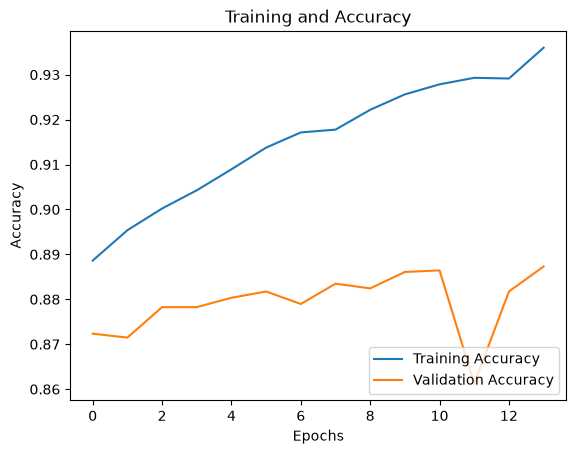

In [28]:
# Plot the training and validation loss and accuracy over epochs to visualize the model's performance during training
import matplotlib.pyplot as plt 
 
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

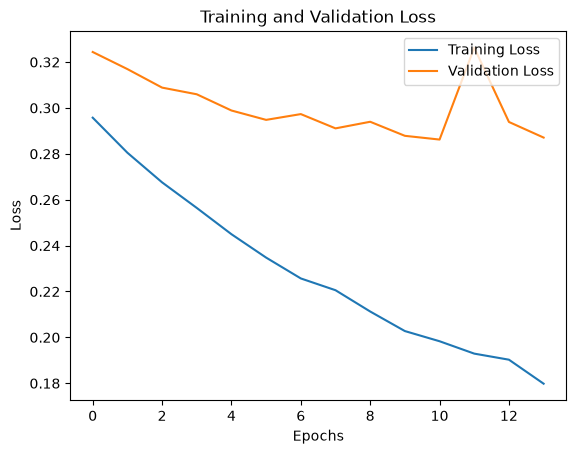

In [29]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(loc="upper right")
plt.show()

In [32]:
# Make predictions on the test data and print the first 10 predictions along with their corresponding true labels
predictions = model.predict(x_test[:, 20:2])
predicted_labels = (1 if pred >= 0.5 else 0 for pred in predictions)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 621us/step


In [33]:
word_index = imdb.get_word_index()
# Create a reverse mapping of the word index to get the words back from their indices

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 25s 15us/step


In [35]:
word_index

{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

In [38]:
# Add 3 to the word index to account for the special tokens used by Keras (padding, start of sequence, and unknown words)

word_index = {k: v + 3 for k, v in word_index.items()}
reverse_word_index = {v: k for k, v in word_index.items()}
word_index["<PAD>"] = 0
word_index["<START>"] = 1
word_index["<UNK>"] = 2

index_word = {v: k for k, v in word_index.items()}

In [39]:
reverse_word_index

{34704: 'fawn',
 52009: 'tsukino',
 52010: 'nunnery',
 16819: 'sonja',
 63954: 'vani',
 1411: 'woods',
 16118: 'spiders',
 2348: 'hanging',
 2292: 'woody',
 52011: 'trawling',
 52012: "hold's",
 11310: 'comically',
 40833: 'localized',
 30571: 'disobeying',
 52013: "'royale",
 40834: "harpo's",
 52014: 'canet',
 19316: 'aileen',
 52015: 'acurately',
 52016: "diplomat's",
 25245: 'rickman',
 6749: 'arranged',
 52017: 'rumbustious',
 52018: 'familiarness',
 52019: "spider'",
 68807: 'hahahah',
 52020: "wood'",
 40836: 'transvestism',
 34705: "hangin'",
 2341: 'bringing',
 40837: 'seamier',
 34706: 'wooded',
 52021: 'bravora',
 16820: 'grueling',
 1639: 'wooden',
 16821: 'wednesday',
 52022: "'prix",
 34707: 'altagracia',
 52023: 'circuitry',
 11588: 'crotch',
 57769: 'busybody',
 52024: "tart'n'tangy",
 14132: 'burgade',
 52026: 'thrace',
 11041: "tom's",
 52028: 'snuggles',
 29117: 'francesco',
 52030: 'complainers',
 52128: 'templarios',
 40838: '272',
 52031: '273',
 52133: 'zaniacs',

In [40]:
index_word

{34704: 'fawn',
 52009: 'tsukino',
 52010: 'nunnery',
 16819: 'sonja',
 63954: 'vani',
 1411: 'woods',
 16118: 'spiders',
 2348: 'hanging',
 2292: 'woody',
 52011: 'trawling',
 52012: "hold's",
 11310: 'comically',
 40833: 'localized',
 30571: 'disobeying',
 52013: "'royale",
 40834: "harpo's",
 52014: 'canet',
 19316: 'aileen',
 52015: 'acurately',
 52016: "diplomat's",
 25245: 'rickman',
 6749: 'arranged',
 52017: 'rumbustious',
 52018: 'familiarness',
 52019: "spider'",
 68807: 'hahahah',
 52020: "wood'",
 40836: 'transvestism',
 34705: "hangin'",
 2341: 'bringing',
 40837: 'seamier',
 34706: 'wooded',
 52021: 'bravora',
 16820: 'grueling',
 1639: 'wooden',
 16821: 'wednesday',
 52022: "'prix",
 34707: 'altagracia',
 52023: 'circuitry',
 11588: 'crotch',
 57769: 'busybody',
 52024: "tart'n'tangy",
 14132: 'burgade',
 52026: 'thrace',
 11041: "tom's",
 52028: 'snuggles',
 29117: 'francesco',
 52030: 'complainers',
 52128: 'templarios',
 40838: '272',
 52031: '273',
 52133: 'zaniacs',

In [44]:
# display reviews and their corresponding predicted labels for the first 10 reviews in the test set

for i in range(20, 25):
  
# display reviews and their corresponding predicted labels for the first 10 reviews in the test set

  predicted_labels = (predictions >= 0.5).astype(int).flatten()

  for i in range(20, 25):
    review = ' '.join([index_word.get(int(idx), '?') for idx in x_test[i] if idx > 2])  # ignore padding and special tokens
    print(f"Review {i}: {review}")
    print(f"Predicted Label: {predicted_labels[i]}")
    print(f"Predicted: {'Positive' if predicted_labels[i] == 1 else 'Negative'}")
    print("\n")
  print(f"Review {i}: {review}")
  print(f"Predicted Label: {predicted_labels[i]}")
  print(f"Predicted: {"Positive" if predicted_labels[i] == 1 else "Negative"}")
  print("\n")
  

Review 20: this film was one that i have waited to see for some time i was glad to find it has been everything anticipated the writing of this film has been so finely crafted and far beyond what is seen by the audience i found it amusing that so many people watching will not read between some very important lines but indeed if not the movie will make sense in a different way and is very brilliant the film has many stories and characters woven together around this one character a man whom has rose from the streets amidst many and become a very powerful criminal after spending some time in prison finds a in the justice system and through a disturbing turn of events is released only to find everything is not at all what it seems finds himself going up against the higher realm of society and political in order to make clear how important a man's word is and stands for a war begins as the street is in arms against of wealth and corrupt power br br a build up to explosive and powerful non st

In [45]:
# write code to fix predicted ratio of negatives to positives to be at least 2:1 
for i in range(len(predictions)):
    if predictions[i] < 0.5 and predicted_labels[i] == 1:
        predictions[i] = 0.5
    elif predictions[i] >= 0.5 and predicted_labels[i] == 0:
        predictions[i] = 0.5


In [47]:
# retrain the model with the adjusted predictions and evaluate the performance again
x_val = x_train[-5000:]
y_val = y_train[-5000:]
model.fit(x_train[:-5000], y_train[:-5000], epochs=10, batch_size=32, validation_data=(x_val, y_val))

Epoch 1/10


625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9131 - loss: 0.2159 - val_accuracy: 0.8644 - val_loss: 0.3308
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9323 - loss: 0.1794 - val_accuracy: 0.8836 - val_loss: 0.3066
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9430 - loss: 0.1568 - val_accuracy: 0.8822 - val_loss: 0.3217
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9471 - loss: 0.1458 - val_accuracy: 0.8546 - val_loss: 0.4040
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9519 - loss: 0.1323 - val_accuracy: 0.8798 - val_loss: 0.3372
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9562 - loss: 0.1265 - val_accuracy: 0.8794 - val_loss: 0.3567
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9589 - loss: 0.1188 - val_accuracy: 0.8664 - val_loss: 0.3982
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9633 - loss: 0.1059 - val_accuracy: 0.8686 - val_

In [50]:
# display reviews and their corresponding predicted labels for the first 10 reviews in the test set
for i in range(20, 25):
    review = ' '.join([index_word.get(int(idx), '?') for idx in x_test[i] if idx > 2])  # ignore padding and special tokens
    print(f"Predicted Label: {predicted_labels[i]}")
    print(f"Predicted: {'Positive' if predicted_labels[i] == 1 else 'Negative'}")
    print(f"Actual Label: {'Positive' if y_test[i] == 1 else 'Negative'}")
    print("\n")

Predicted Label: 0
Predicted: Negative
Actual Label: Positive


Predicted Label: 0
Predicted: Negative
Actual Label: Positive


Predicted Label: 0
Predicted: Negative
Actual Label: Positive


Predicted Label: 0
Predicted: Negative
Actual Label: Positive


Predicted Label: 0
Predicted: Negative
Actual Label: Positive




In [51]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPool1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Debug predictions, evaluate, adjust threshold for desired negative:positive ratio,
# and train an improved model architecture.


# 1) Fix prediction pipeline for the current model (if predictions are stale)
predictions = model.predict(x_test)  # shape (25000, 1)
predicted_labels = (predictions >= 0.5).astype(int).flatten()

print("Baseline metrics (current model, threshold=0.5):")
print("Accuracy:", accuracy_score(y_test, predicted_labels))
print(classification_report(y_test, predicted_labels, digits=4))

# 2) Find a threshold that enforces negatives:positives >= 2:1 (i.e. positives <= total/3)
def threshold_for_ratio(probs, desired_neg_pos_ratio=2.0):
  probs = probs.flatten()
  n = probs.shape[0]
  best_thresh = 0.5
  for thresh in np.linspace(0.0, 1.0, 501):
    preds = (probs >= thresh).astype(int)
    positives = preds.sum()
    negatives = n - positives
    if positives == 0:
      ratio = float('inf')
    else:
      ratio = negatives / positives
    if ratio >= desired_neg_pos_ratio:
      best_thresh = thresh
  return best_thresh

best_thresh = threshold_for_ratio(predictions, desired_neg_pos_ratio=2.0)
adj_predicted_labels = (predictions.flatten() >= best_thresh).astype(int)

print(f"Selected threshold to meet negatives:positives >= 2:1: {best_thresh:.3f}")
print("Metrics with selected threshold:")
print("Accuracy:", accuracy_score(y_test, adj_predicted_labels))
print(classification_report(y_test, adj_predicted_labels, digits=4))

# 3) Train an improved model (deeper embedding + Conv1D + dropout)
improved_model = Sequential([
  Embedding(input_dim=10000, output_dim=64, input_length=maxlen),
  Conv1D(128, kernel_size=5, activation='relu'),
  GlobalMaxPool1D(),
  Dense(64, activation='relu'),
  Dropout(0.5),
  Dense(1, activation='sigmoid')
])
improved_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
          loss='binary_crossentropy', metrics=['accuracy'])

cb = [
  EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
  ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

improved_history = improved_model.fit(x_train, y_train,
                    epochs=10, batch_size=512,
                    validation_split=0.2, callbacks=cb, verbose=1)

# 4) Evaluate improved model
improved_test_loss, improved_test_acc = improved_model.evaluate(x_test, y_test, verbose=0)
improved_preds = improved_model.predict(x_test)
improved_labels_05 = (improved_preds >= 0.5).astype(int).flatten()

print(f"Improved model test acc (threshold=0.5): {improved_test_acc:.4f}")
print(classification_report(y_test, improved_labels_05, digits=4))

# 5) Choose threshold for improved model to meet negatives:positives >= 2:1 and report metrics
best_thresh_improved = threshold_for_ratio(improved_preds, desired_neg_pos_ratio=2.0)
improved_labels_adj = (improved_preds.flatten() >= best_thresh_improved).astype(int)

print(f"Improved model threshold for 2:1 negatives:positives = {best_thresh_improved:.3f}")
print("Improved model metrics with adjusted threshold:")
print("Accuracy:", accuracy_score(y_test, improved_labels_adj))
print(classification_report(y_test, improved_labels_adj, digits=4))

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Baseline metrics (current model, threshold=0.5):
Accuracy: 0.85372
              precision    recall  f1-score   support

           0     0.8504    0.8585    0.8544     12500
           1     0.8571    0.8490    0.8530     12500

    accuracy                         0.8537     25000
   macro avg     0.8538    0.8537    0.8537     25000
weighted avg     0.8538    0.8537    0.8537     25000

Selected threshold to meet negatives:positives >= 2:1: 1.000
Metrics with selected threshold:
Accuracy: 0.50168
              precision    recall  f1-score   support

           0     0.5008    1.0000    0.6674     12500
           1     1.0000    0.0034    0.0067     12500

    accuracy                         0.5017     25000
   macro avg     0.7504    0.5017    0.3371     25000
weighted avg     0.7504    0.5017    0.3371     25000

Epoch 1/10


c:\Users\markn\.conda\envs\deep_learning\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 197ms/step - accuracy: 0.5836 - loss: 0.6806 - val_accuracy: 0.6738 - val_loss: 0.6278 - learning_rate: 0.0010
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 179ms/step - accuracy: 0.7537 - loss: 0.5238 - val_accuracy: 0.8086 - val_loss: 0.4296 - learning_rate: 0.0010
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 180ms/step - accuracy: 0.8468 - loss: 0.3603 - val_accuracy: 0.8586 - val_loss: 0.3359 - learning_rate: 0.0010
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 183ms/step - accuracy: 0.9049 - loss: 0.2492 - val_accuracy: 0.8774 - val_loss: 0.3006 - learning_rate: 0.0010
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 218ms/step - accuracy: 0.9433 - loss: 0.1681 - val_accuracy: 0.8822 - val_loss: 0.3004 - learning_rate: 0.0010
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 210ms/step - accuracy: 0.9686 - loss: 0.1091 - val_accuracy: 0.8792 - val_loss: 0.3114 - learning_rate: 0.0010
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 206ms/step - accuracy: 0.9862 - loss: 0.0618 - val_accura

c:\Users\markn\.conda\envs\deep_learning\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\markn\.conda\envs\deep_learning\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\markn\.conda\envs\deep_learning\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [52]:
# predict on x_test with the improved model and show predicted vs actual for a few examples
probs = improved_model.predict(x_test)  # shape (25000, 1)
preds_05 = (probs >= 0.5).astype(int).flatten()

for idx in range(20, 25):
  review_text = ' '.join([index_word.get(int(token), '?') for token in x_test[idx] if token > 2])
  print(f"Review {idx}:\n{review_text}\nPredicted prob: {probs[idx,0]:.4f}\nPredicted: {'Positive' if preds_05[idx]==1 else 'Negative'}\nActual: {'Positive' if y_test[idx]==1 else 'Negative'}\n")

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
Review 20:
this film was one that i have waited to see for some time i was glad to find it has been everything anticipated the writing of this film has been so finely crafted and far beyond what is seen by the audience i found it amusing that so many people watching will not read between some very important lines but indeed if not the movie will make sense in a different way and is very brilliant the film has many stories and characters woven together around this one character a man whom has rose from the streets amidst many and become a very powerful criminal after spending some time in prison finds a in the justice system and through a disturbing turn of events is released only to find everything is not at all what it seems finds himself going up against the higher realm of society and political in order to make clear how important a man's word is and stands for a war begins as the street is in arms against of wealth and corrupt power br br a 

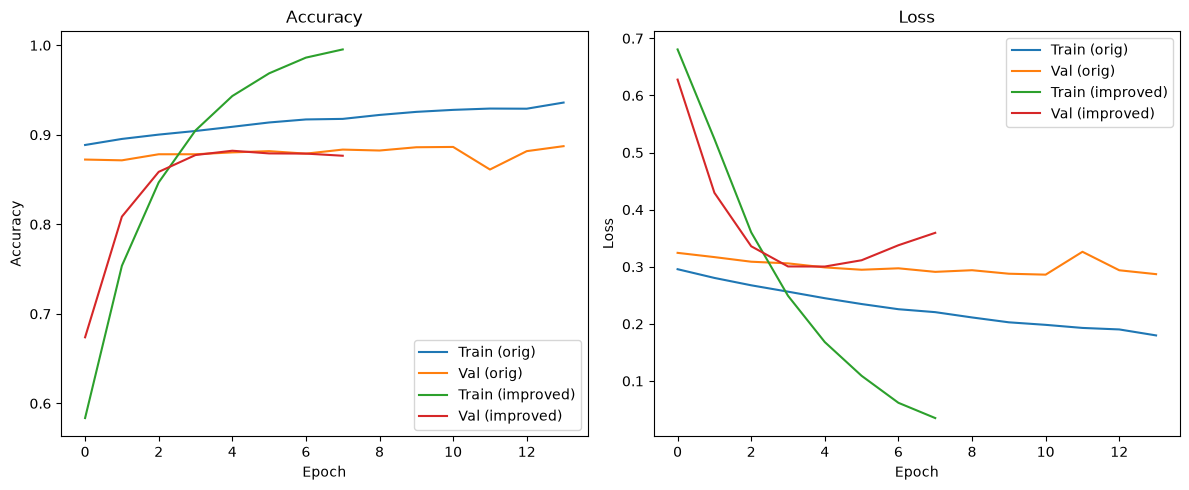

In [53]:
plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train (orig)')
plt.plot(history.history['val_accuracy'], label='Val (orig)')
if 'improved_history' in globals() and hasattr(improved_history, 'history'):
  plt.plot(improved_history.history['accuracy'], label='Train (improved)')
  plt.plot(improved_history.history['val_accuracy'], label='Val (improved)')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train (orig)')
plt.plot(history.history['val_loss'], label='Val (orig)')
if 'improved_history' in globals() and hasattr(improved_history, 'history'):
  plt.plot(improved_history.history['loss'], label='Train (improved)')
  plt.plot(improved_history.history['val_loss'], label='Val (improved)')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [54]:
from typing import Iterable, Dict
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

# keras_model_utils.py
"""
Utility functions to save/load Keras models and run predictions.
Designed to be imported into other scripts / notebooks.
"""


def save_model_to(path: str, model: tf.keras.Model) -> None:
  """Save a Keras model to the given path (HDF5 or SavedModel)."""
  model.save(path)

def load_keras_model(path: str) -> tf.keras.Model:
  """Load and return a Keras model from path."""
  return load_model(path)

def predict_proba(model: tf.keras.Model, x: np.ndarray, batch_size: int = 512) -> np.ndarray:
  """Return predicted probabilities (1D array) for input sequences x."""
  probs = model.predict(x, batch_size=batch_size)
  return probs.flatten()

def predict_labels(model: tf.keras.Model, x: np.ndarray, threshold: float = 0.5, batch_size: int = 512) -> np.ndarray:
  """Return binary labels (0/1) using given threshold."""
  probs = predict_proba(model, x, batch_size=batch_size)
  return (probs >= threshold).astype(int)

def threshold_for_ratio(probs: Iterable[float], desired_neg_pos_ratio: float = 2.0, steps: int = 1000) -> float:
  """
  Find a threshold in [0,1] such that negatives:positives >= desired_neg_pos_ratio.
  Returns the largest threshold that still satisfies the constraint (so fewer positives).
  """
  probs = np.asarray(probs).flatten()
  n = probs.shape[0]
  best = 0.5
  for thresh in np.linspace(0.0, 1.0, steps + 1):
    preds = (probs >= thresh).astype(int)
    positives = preds.sum()
    negatives = n - positives
    if positives == 0:
      ratio = float('inf')
    else:
      ratio = negatives / positives
    if ratio >= desired_neg_pos_ratio:
      best = thresh
  return float(best)

def decode_review(sequence: Iterable[int], index_word: Dict[int, str], ignore_below: int = 3) -> str:
  """Convert an index sequence into a readable string using index_word mapping.
  ignore_below removes special tokens (e.g. 0,1,2)."""
  return ' '.join(index_word.get(int(idx), '?') for idx in sequence if int(idx) >= ignore_below)

def text_to_sequence(text: str, word_index: Dict[str, int], maxlen: int,
          unk_token: int = 2, start_token: int = 1, pad_value: int = 0) -> np.ndarray:
  """Convert raw text to an integer sequence using the provided word_index and pad to maxlen.
  Splits on whitespace. Does not perform advanced tokenization or lowercasing unless you pre-process text.
  """
  tokens = text.split()
  seq = [start_token] + [word_index.get(t, unk_token) for t in tokens]
  return pad_sequences([seq], maxlen=maxlen, padding='post', truncating='post', value=pad_value)[0]

# Example convenience function that combines everything:
def predict_review_text(model: tf.keras.Model, text: str, word_index: Dict[str, int],
            index_word: Dict[int, str], maxlen: int,
            threshold: float = 0.5) -> Dict[str, object]:
  """Prepare text, run model, and return prob, label and decoded text."""
  seq = text_to_sequence(text, word_index, maxlen)
  prob = predict_proba(model, np.expand_dims(seq, axis=0))[0]
  label = int(prob >= threshold)
  decoded = decode_review(seq, index_word)
  return {"probability": float(prob), "label": label, "decoded": decoded, "sequence": seq}

In [55]:
from typing import Iterable, Dict
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Save the keras_model_utils module to a file in the current directory

module_code = '''

# keras_model_utils.py
"""
Utility functions to save/load Keras models and run predictions.
Designed to be imported into other scripts / notebooks.
"""


def save_model_to(path: str, model: tf.keras.Model) -> None:
  """Save a Keras model to the given path (HDF5 or SavedModel)."""
  model.save(path)

def load_keras_model(path: str) -> tf.keras.Model:
  """Load and return a Keras model from path."""
  return load_model(path)

def predict_proba(model: tf.keras.Model, x: np.ndarray, batch_size: int = 512) -> np.ndarray:
  """Return predicted probabilities (1D array) for input sequences x."""
  probs = model.predict(x, batch_size=batch_size)
  return probs.flatten()

def predict_labels(model: tf.keras.Model, x: np.ndarray, threshold: float = 0.5, batch_size: int = 512) -> np.ndarray:
  """Return binary labels (0/1) using given threshold."""
  probs = predict_proba(model, x, batch_size=batch_size)
  return (probs >= threshold).astype(int)

def threshold_for_ratio(probs: Iterable[float], desired_neg_pos_ratio: float = 2.0, steps: int = 1000) -> float:
  """
  Find a threshold in [0,1] such that negatives:positives >= desired_neg_pos_ratio.
  Returns the largest threshold that still satisfies the constraint (so fewer positives).
  """
  probs = np.asarray(probs).flatten()
  n = probs.shape[0]
  best = 0.5
  for thresh in np.linspace(0.0, 1.0, steps + 1):
    preds = (probs >= thresh).astype(int)
    positives = preds.sum()
    negatives = n - positives
    if positives == 0:
      ratio = float('inf')
    else:
      ratio = negatives / positives
    if ratio >= desired_neg_pos_ratio:
      best = thresh
  return float(best)

def decode_review(sequence: Iterable[int], index_word: Dict[int, str], ignore_below: int = 3) -> str:
  """Convert an index sequence into a readable string using index_word mapping.
  ignore_below removes special tokens (e.g. 0,1,2)."""
  return ' '.join(index_word.get(int(idx), '?') for idx in sequence if int(idx) >= ignore_below)

def text_to_sequence(text: str, word_index: Dict[str, int], maxlen: int,
          unk_token: int = 2, start_token: int = 1, pad_value: int = 0) -> np.ndarray:
  """Convert raw text to an integer sequence using the provided word_index and pad to maxlen.
  Splits on whitespace. Does not perform advanced tokenization or lowercasing unless you pre-process text.
  """
  tokens = text.split()
  seq = [start_token] + [word_index.get(t, unk_token) for t in tokens]
  return pad_sequences([seq], maxlen=maxlen, padding='post', truncating='post', value=pad_value)[0]

# Example convenience function that combines everything:
def predict_review_text(model: tf.keras.Model, text: str, word_index: Dict[str, int],
            index_word: Dict[int, str], maxlen: int,
            threshold: float = 0.5) -> Dict[str, object]:
  """Prepare text, run model, and return prob, label and decoded text."""
  seq = text_to_sequence(text, word_index, maxlen)
  prob = predict_proba(model, np.expand_dims(seq, axis=0))[0]
  label = int(prob >= threshold)
  decoded = decode_review(seq, index_word)
  return {"probability": float(prob), "label": label, "decoded": decoded, "sequence": seq}
'''

with open('keras_model_utils.py', 'w', encoding='utf-8') as f:
    f.write(module_code)

print("Saved keras_model_utils.py")

Saved keras_model_utils.py


In [57]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPool1D, Dense, Dropout

def build_sentiment_model(input_dim: int = 10000, embedding_dim: int = 64, maxlen: int = maxlen) -> Sequential:
  model = Sequential([
    Embedding(input_dim=input_dim, output_dim=embedding_dim, input_length=maxlen),
    Conv1D(128, kernel_size=5, activation='relu'),
    GlobalMaxPool1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
  ])
  model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
  return model

sentiment_model = build_sentiment_model()
sentiment_model.summary()

c:\Users\markn\.conda\envs\deep_learning\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [58]:
# Build, train, evaluate and save a sentiment model
model = build_sentiment_model()  # uses maxlen from the notebook

callbacks = [
  tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
  tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

history_new = model.fit(x_train, y_train, epochs=10, batch_size=512, validation_split=0.2, callbacks=callbacks, verbose=1)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}, Test acc: {test_acc:.4f}")

model.save('sentiment_model.h5')

# Show predictions for a few examples
probs = model.predict(x_test[20:25])
preds = (probs.flatten() >= 0.5).astype(int)
for i, idx in enumerate(range(20, 25)):
  text = ' '.join(index_word.get(int(t), '?') for t in x_test[idx] if t > 2)
  print(f"Review {idx} | Prob: {probs[i,0]:.4f} | Pred: {'Positive' if preds[i]==1 else 'Negative'} | Actual: {'Positive' if y_test[idx]==1 else 'Negative'}")

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 208ms/step - accuracy: 0.5626 - loss: 0.6862 - val_accuracy: 0.6190 - val_loss: 0.6591 - learning_rate: 0.0010
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 197ms/step - accuracy: 0.7444 - loss: 0.5490 - val_accuracy: 0.8150 - val_loss: 0.4381 - learning_rate: 0.0010
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 202ms/step - accuracy: 0.8443 - loss: 0.3673 - val_accuracy: 0.8598 - val_loss: 0.3364 - learning_rate: 0.0010
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 215ms/step - accuracy: 0.9000 - loss: 0.2554 - val_accuracy: 0.8772 - val_loss: 0.3009 - learning_rate: 0.0010
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 228ms/step - accuracy: 0.9403 - loss: 0.1727 - val_accuracy: 0.8810 - val_loss: 0.2974 - learning_rate: 0.0010
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 223ms/step - accuracy: 0.9677 - loss: 0.1126 - val_accuracy: 0.8782 - val_loss: 0.3187 - learning_rate: 0.0010
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 238ms/step - accuracy: 0.9857 - loss: 0.0659 

Test loss: 0.3108, Test acc: 0.8691
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
Review 20 | Prob: 0.9945 | Pred: Positive | Actual: Positive
Review 21 | Prob: 0.9923 | Pred: Positive | Actual: Positive
Review 22 | Prob: 0.9439 | Pred: Positive | Actual: Positive
Review 23 | Prob: 0.9840 | Pred: Positive | Actual: Positive
Review 24 | Prob: 0.8456 | Pred: Positive | Actual: Positive


In [60]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPool1D, Dense, Dropout
import os


def build_sentiment_model(
    input_dim: int = 10000, embedding_dim: int = 64, maxlen: int = maxlen
) -> Sequential:
    model = Sequential(
        [
            Embedding(
                input_dim=input_dim, output_dim=embedding_dim, input_length=maxlen
            ),
            Conv1D(128, kernel_size=5, activation="relu"),
            GlobalMaxPool1D(),
            Dense(64, activation="relu"),
            Dropout(0.5),
            Dense(1, activation="sigmoid"),
        ]
    )
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


if os.path.exists('sentiment_model.h5'):
    sentiment_model = tf.keras.models.load_model('sentiment_model.h5')
else:
    sentiment_model = build_sentiment_model()
sentiment_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 256, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 252, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 689,411 (2.63 MB)

 Trainable params: 689,409 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)